# Exercise 6: Missing Data

**Authors**: 
- Ariful Islam Riane : 3981886
- Pedro Fernandez Tonso : 3983781
- Group Number : 19

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import arff
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

np.random.seed(42)

## 1. Load and Prepare Data

In [2]:
def load_arff(file_path):
    ar, meta = arff.loadarff(file_path)
    return pd.DataFrame(ar), meta

file_path = Path('../databank/00_raw/uci-large/credit-a.arff')
if not file_path.exists():
    file_path = Path('dq-lab-1/databank/00_raw/uci-large/credit-a.arff')

data, _ = load_arff(file_path)
data.dropna(inplace=True)

for col, typ in zip(data.columns, data.dtypes):
    if typ == 'object':
        data[col] = data[col].map(lambda x: x.decode() if isinstance(x, bytes) else x)

X = pd.get_dummies(data.drop('class', axis=1))
X = X.drop([col for col in X.columns if col.endswith('_?')], axis=1)
y = data['class']

## 2. Missing Data Experiment Functions

In [3]:
def introduce_missing_values(df, columns, missing_level=0.05, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    df_missing = df.copy()

    for col in columns:
        n_missing = int(len(df_missing) * missing_level)
        if n_missing == 0:
            continue
        missing_idx = rng.choice(len(df_missing), size=n_missing, replace=False)
        df_missing.iloc[missing_idx, df_missing.columns.get_loc(col)] = None

    return df_missing


def train_and_eval(train_df, test_df):
    y_train = train_df['class']
    y_test = test_df['class']

    X_train_raw = train_df.drop('class', axis=1)
    X_test_raw = test_df.drop('class', axis=1)

    # One-hot encode train and test together so the resulting columns line up
    combined = pd.concat([X_train_raw, X_test_raw], keys=['train', 'test'])
    combined_encoded = pd.get_dummies(combined)
    combined_encoded = combined_encoded.drop(
        [c for c in combined_encoded.columns if c.endswith('_?')], axis=1
    )

    X_train = combined_encoded.xs('train')
    X_test = combined_encoded.xs('test')

    clf = GaussianNB()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    return accuracy_score(y_test, y_pred)


def run_missing_data_experiment(data, columns, missing_levels=None, seed=42):
    if missing_levels is None:
        missing_levels = [0.0, 0.01, 0.05, 0.10, 0.20, 0.30, 0.50]

    rng = np.random.default_rng(seed)
    deletion_acc = {}
    imputation_acc = {}

    for level in missing_levels:
        # Corrupt the chosen columns across the WHOLE dataset first (same approach as
        # Exercise 1), then split into train/test so both parts contain missing values
        data_missing = introduce_missing_values(data, columns, missing_level=level, rng=rng)
        train_idx, test_idx = train_test_split(
            data_missing.index, train_size=0.7, test_size=0.3, random_state=100
        )
        train_raw = data_missing.loc[train_idx]
        test_raw = data_missing.loc[test_idx]

        # --- Approach 1: list-wise deletion ---
        train_deleted = train_raw.dropna(subset=columns)
        test_deleted = test_raw.dropna(subset=columns)
        if len(train_deleted) > 0 and len(test_deleted) > 0:
            deletion_acc[level] = train_and_eval(train_deleted, test_deleted)
        else:
            deletion_acc[level] = np.nan

        # --- Approach 2: mean/mode imputation (statistics from TRAIN only) ---
        train_imputed = train_raw.copy()
        test_imputed = test_raw.copy()
        for col in columns:
            if pd.api.types.is_numeric_dtype(data[col]):
                fill_value = train_raw[col].mean()
            else:
                fill_value = train_raw[col].mode(dropna=True).iloc[0]
            train_imputed[col] = train_imputed[col].fillna(fill_value)
            test_imputed[col] = test_imputed[col].fillna(fill_value)

        imputation_acc[level] = train_and_eval(train_imputed, test_imputed)

    return deletion_acc, imputation_acc

## 3. Plot: Accuracy vs. Missing Data Level

In [4]:
def plot_missing_data_experiment(deletion_acc, imputation_acc, title, baseline_acc=None):
    levels = list(deletion_acc.keys())

    plt.figure(figsize=(8, 5))
    plt.plot(
        levels, list(deletion_acc.values()),
        marker='o', linewidth=2, markersize=6, label='List-wise Deletion',
    )
    plt.plot(
        levels, list(imputation_acc.values()),
        marker='o', linewidth=2, markersize=6, label='Mean/Mode Imputation',
    )

    if baseline_acc is not None:
        plt.axhline(
            baseline_acc, color='red', linestyle='--', alpha=0.7,
            label=f'Baseline (0% missing): {baseline_acc:.4f}'
        )

    plt.title(title, fontsize=13)
    plt.xlabel('Missing Data Level (Proportion of Rows Affected)', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().xaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{int(round(v*100))}%')
    )
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

## 4. Missing Data in A2 (Age, numerical)

We corrupt `A2` at increasing levels and compare list-wise deletion against mean imputation. The 0% level in both curves is the same clean baseline.

Missing 0.00 | Deletion: 0.8250 | Imputation: 0.8250
Missing 0.01 | Deletion: 0.8274 | Imputation: 0.8250
Missing 0.05 | Deletion: 0.8187 | Imputation: 0.8250
Missing 0.10 | Deletion: 0.8466 | Imputation: 0.8300
Missing 0.20 | Deletion: 0.8535 | Imputation: 0.8250
Missing 0.30 | Deletion: 0.8014 | Imputation: 0.8250
Missing 0.50 | Deletion: 0.8218 | Imputation: 0.8250


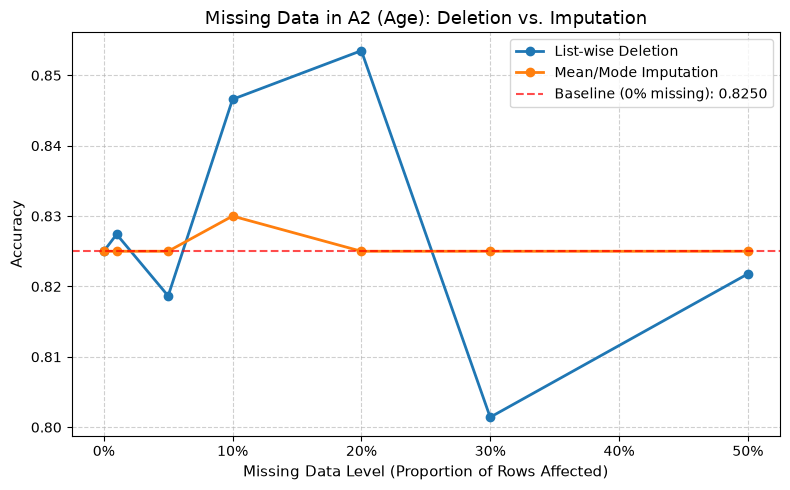

In [5]:
deletion_acc_a2, imputation_acc_a2 = run_missing_data_experiment(data, ['A2'])

baseline_accuracy_a2 = deletion_acc_a2[0.0]

for level in deletion_acc_a2:
    print(f"Missing {level:.2f} | Deletion: {deletion_acc_a2[level]:.4f} "
          f"| Imputation: {imputation_acc_a2[level]:.4f}")

plot_missing_data_experiment(
    deletion_acc_a2, imputation_acc_a2,
    title='Missing Data in A2 (Age): Deletion vs. Imputation',
    baseline_acc=baseline_accuracy_a2,
)

## 5. Missing Data in A6 (Education Level, categorical)

Same experiment, now on a categorical attribute, using mode imputation instead of mean.

Missing 0.00 | Deletion: 0.8250 | Imputation: 0.8250
Missing 0.01 | Deletion: 0.8274 | Imputation: 0.8250
Missing 0.05 | Deletion: 0.8187 | Imputation: 0.8250
Missing 0.10 | Deletion: 0.8466 | Imputation: 0.8200
Missing 0.20 | Deletion: 0.8535 | Imputation: 0.8050
Missing 0.30 | Deletion: 0.8014 | Imputation: 0.8300
Missing 0.50 | Deletion: 0.8218 | Imputation: 0.8200


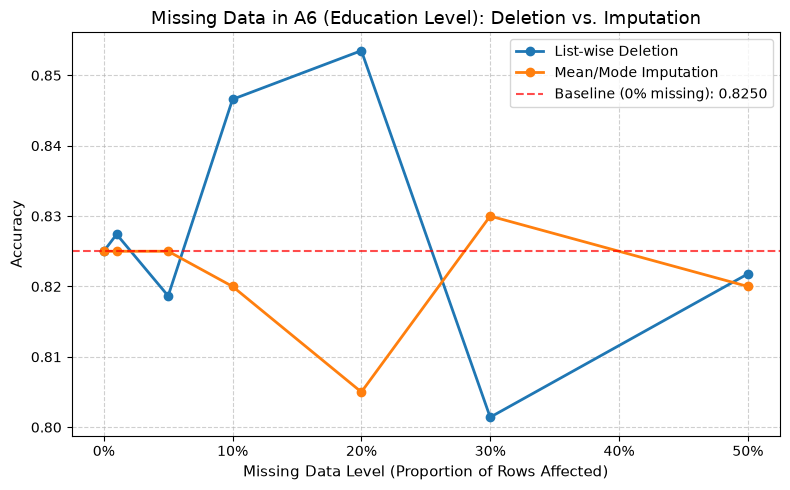

In [6]:
deletion_acc_a6, imputation_acc_a6 = run_missing_data_experiment(data, ['A6'])

baseline_accuracy_a6 = deletion_acc_a6[0.0]

for level in deletion_acc_a6:
    print(f"Missing {level:.2f} | Deletion: {deletion_acc_a6[level]:.4f} "
          f"| Imputation: {imputation_acc_a6[level]:.4f}")

plot_missing_data_experiment(
    deletion_acc_a6, imputation_acc_a6,
    title='Missing Data in A6 (Education Level): Deletion vs. Imputation',
    baseline_acc=baseline_accuracy_a6,
)

## Experiment interpretation

We corrupt one attribute at a time across the whole dataset (same approach as Exercise 1), then split into train/test, so both parts contain missing values at each level. We then compare two cleaning strategies: list-wise deletion, which drops any row (train or test) with a missing value in the chosen column, and mean/mode imputation, which fills missing values using the mean (numerical) or mode (categorical) computed only from the training rows, then applies that same fill value to both train and test. The 0% level reproduces the clean baseline for both curves.

## Takeaways

We chose 'A2' (Age, numerical) and 'A6' (Education level, categorical) as our missing data targets, to compare a numerical vs a categorical attribute and deletion vs imputation.

1. Imputation stays flat across all missing levels (0.805-0.830), since filling with the mean/mode barely changes what the model sees.
2. Deletion is noisier (0.80-0.85), as shrinking the train/test sets makes results more sensitive to which rows get dropped.
3. Deletion sometimes scores higher than imputation (e.g. at 10-20% missing on A2), likely a lucky split rather than a real advantage.
4. Neither A2 nor A6 seems strongly tied to the class label, since accuracy stays close to the 0.8250 baseline even at 50% missing.